In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
# read data
path = r"C:\Users\mejse\Documents\uni\4. semester\Dataprojekt\projekt\Federated-dental-risk-vol2\data\processed\A\global_test_set_non-iid.csv"
path_big = r'C:\Users\mejse\Documents\uni\4. semester\Dataprojekt\projekt\Federated-dental-risk-vol2\data\raw\synthetic_dataset_A_non-iid.csv'
df = pd.read_csv(path_big)
df = df[:20000]

In [2]:
# Add new column 'Complication', 1 if one or more of the 4 complications happen 0 otherwise
df["Complication"] = ((df["Risk_SecondaryInfection"] == 1) | (df["Risk_NerveDysesthesia"]==1) | (df["Risk_Bleeding"] == 1) | (df["Risk_Category_AlveolarOsteitis"]==1)).astype(int)

In [3]:
# This is a list of all the colums
cols = df.columns.tolist()
print(cols)

['Client', 'Patient', 'Age', 'Sex', 'Pain', 'Swelling', 'Trismus', 'Pericoronitis', 'Caries_Wisdom', 'Caries_Adjacent', 'Periodontal_Status', 'Root_Development', 'Tooth_Mobility', 'Tooth_Angulation', 'Impaction_Depth', 'Proximity_Nerve', 'Root_Count', 'Root_Curvature', 'Bone_Density', 'Cyst', 'Diabetes', 'Osteoporosis', 'Clotting_Disorder', 'Smoking', 'Bisphosphonates', 'Prev_Extraction_Issue', 'Surgical_Extraction_Type', 'Score_1', 'Score_2', 'Score_3', 'Prob_1', 'Prob_2', 'Prob_3', 'Removal_Indicated', 'Removal_Prob', 'Risk_AlveolarOsteitis', 'Risk_AlveolarOsteitis_Prob', 'Risk_SecondaryInfection', 'Risk_SecondaryInfection_Prob', 'Risk_NerveDysesthesia', 'Risk_NerveDysesthesia_Prob', 'Risk_Bleeding', 'Risk_Bleeding_Prob', 'Risk_Category_AlveolarOsteitis', 'Risk_Category_SecondaryInfection', 'Risk_Category_NerveDysesthesia', 'Risk_Category_Bleeding', 'Risk_Category_Composite', 'Complication']


# Binary

## med Sklearn (uden plots)

In [ ]:
# Add new column 'Complication', 1 if one or more of the 4 complications happen 0 otherwise
df["Complication"] = ((df["Risk_SecondaryInfection"] == 1) | (df["Risk_NerveDysesthesia"]==1) | (df["Risk_Bleeding"] == 1) | (df["Risk_Category_AlveolarOsteitis"]==1)).astype(int)

In [ ]:
# choose features and target
features = df.columns.tolist()[1:27]
X = df[features]
y = df['Complication']

# Split into training and test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=16))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)


# import the metrics class
#from sklearn import metrics

#cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
#cnf_matrix

from sklearn.metrics import classification_report
target_names = ['no complication', 'complication']
print(classification_report(y_test, y_pred, target_names=target_names))


                 precision    recall  f1-score   support

no complication       0.63      0.89      0.74       443
   complication       0.60      0.24      0.34       307

       accuracy                           0.62       750
      macro avg       0.62      0.57      0.54       750
   weighted avg       0.62      0.62      0.58       750



## Centralized

In [4]:
def prepare_data(df,begin = 1, end = 27, cli = False):
    # Prepare data
    features = df.columns.tolist()[begin:end]
    X = df[features].values
    y = df['Complication'].values
    # Scale data (normalization)
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    if cli:
        X = np.c_[df['Client'],np.ones(X.shape[0]), X]
    else:
        X = np.c_[np.ones(X.shape[0]), X]

    # Split into training and test set
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16)
    
    return X_train, X_test, y_train, y_test

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Loss function (cross entropy)
def compute_loss(y, p):
    epsilon = 1e-15  # avoid log(0)
    p = np.clip(p, epsilon, 1 - epsilon)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def train_centralized(X_train, y_train, n_iter = 10, alpha = 0.5 ):

    # Initialize weights
    np.random.seed(16)
    w = np.zeros(X_train.shape[1])

    loss_history = []

    for _ in range(n_iter):
        z = X_train @ w
        p = sigmoid(z)
        
        loss = compute_loss(y_train, p)
        loss_history.append(loss)
        
        n = len(y_train)
        
        # Gradient
        gradient = (X_train.T @ (p - y_train)) / n
        
        # Hessian
        W = np.diag(p * (1 - p))
        H = (X_train.T @ W @ X_train) / n
        
        # Stabilize Hessian
        H += 1e-5 * np.eye(H.shape[0])
        
        # Newton step (stable)
        w -= alpha * np.linalg.solve(H, gradient)
        
        

    # Plot loss curve
    plt.plot(loss_history)
    plt.xlabel("Iteration")
    plt.ylabel("Log Loss")
    plt.title("Training Loss over Iterations")
    plt.show()

    return w

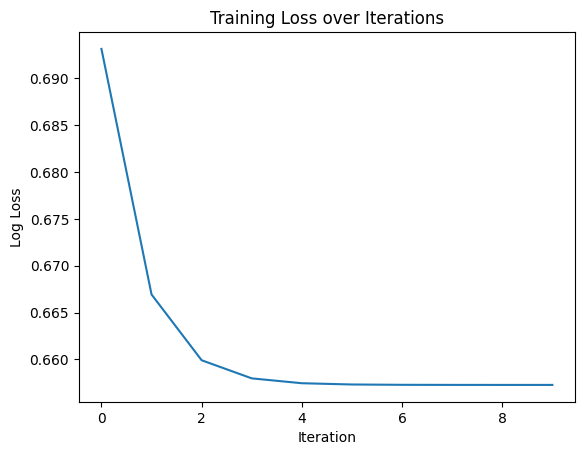

In [5]:
X_train, X_test, y_train, y_test = prepare_data(df)
w = train_centralized(X_train,y_train)

In [7]:
def predict_and_evaluate(X_test, y_test, w, threshold = 0.3):
    z_test = X_test @ w
    p_test = sigmoid(z_test)
    y_pred = (p_test >= threshold).astype(int)

    from sklearn.metrics import classification_report

    target_names = ['no complication', 'complication']
    print(classification_report(y_test, y_pred, target_names=target_names))

    return y_pred

In [8]:
y_pred = predict_and_evaluate(X_test, y_test, w)

                 precision    recall  f1-score   support

no complication       0.74      0.19      0.30      3073
   complication       0.41      0.89      0.56      1927

       accuracy                           0.46      5000
      macro avg       0.57      0.54      0.43      5000
   weighted avg       0.61      0.46      0.40      5000



## local

In [9]:
X_train, X_test, y_train, y_test = prepare_data(df, cli=True)
np.unique(X_train[:,0])

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

In [10]:
def train_local(X_train, y_train, n_iter = 10, alpha = 0.5 ):

    client = X_train[:,0]
    X_train = X_train[:,1:]
    

    w = []
    loss_history = []

    for c in np.unique(client):
        X_train_c = X_train[client == c]
        y_train_c = y_train[client == c]
        
        # Initialize weights
        np.random.seed(16)
        c_w = np.zeros(X_train_c.shape[1])

        c_loss_history = []

        for _ in range(n_iter):
            z = X_train_c @ c_w
            p = sigmoid(z)
            
            loss = compute_loss(y_train_c, p)
            c_loss_history.append(loss)
            
            n = len(y_train_c)
            
            # Gradient
            gradient = (X_train_c.T @ (p - y_train_c)) / n
            
            # Hessian
            W = np.diag(p * (1 - p))
            H = (X_train_c.T @ W @ X_train_c) / n
            
            # Stabilize Hessian
            H += 1e-5 * np.eye(H.shape[0])
            
            # Newton step (stable)
            c_w -= alpha * np.linalg.solve(H, gradient)
        
        w.append(c_w)
        loss_history.append(c_loss_history)

    w_all = np.mean(w, axis=0)

    # Plot loss curves
    for i in range(10):
        plt.plot(loss_history[i], label=f'client = {i+1}')
    plt.legend()
    plt.xlabel("Iteration")
    plt.ylabel("Log Loss")
    plt.title("Training Loss over Iterations")
    plt.show()

    return w_all

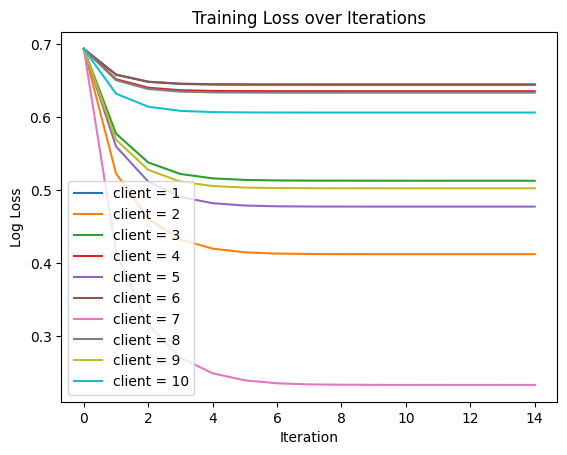

In [11]:
w = train_local(X_train, y_train, n_iter=15)

In [13]:
y_pred = predict_and_evaluate(X_test[:,1:],y_test,w)

                 precision    recall  f1-score   support

no complication       0.85      0.30      0.44      3073
   complication       0.45      0.91      0.60      1927

       accuracy                           0.54      5000
      macro avg       0.65      0.61      0.52      5000
   weighted avg       0.69      0.54      0.50      5000



## Federated

In [26]:
def local_train(X, y, w, lr=0.01, local_epochs=5):
    w_local = w.copy()
    
    for _ in range(local_epochs):
        z = X @ w_local
        p = sigmoid(z)
        
        gradient = (X.T @ (p - y)) / len(y)
        
        w_local -= lr * gradient
    
    return w_local

def train_federated_FedAvg(X_train, y_train, n_rounds=10, lr=0.01, local_epochs=5, cli=True):
    
    client = X_train[:, 0]
    X_train = X_train[:, 1:]
    
    w = np.zeros(X_train.shape[1])
    loss_history = []

    for r in range(n_rounds):
        
        w_list = []
        n_samples = []

        # Train per client
        for c in np.unique(client):
            X_c = X_train[client == c]
            y_c = y_train[client == c]

            w_c = local_train(X_c, y_c, w, lr, local_epochs)

            w_list.append(w_c)
            n_samples.append(len(y_c))

        # Weighted averaging
        total_samples = sum(n_samples)

        w = sum(
            (n / total_samples) * w_c
            for w_c, n in zip(w_list, n_samples)
        )

        # Compute global loss
        z = X_train @ w
        p = sigmoid(z)
        loss = compute_loss(y_train, p)
        loss_history.append(loss)


    plt.plot(loss_history)
    plt.xlabel("Round")
    plt.ylabel("Log Loss")
    plt.title("Training Loss over Rounds")
    plt.show()
    
    return w


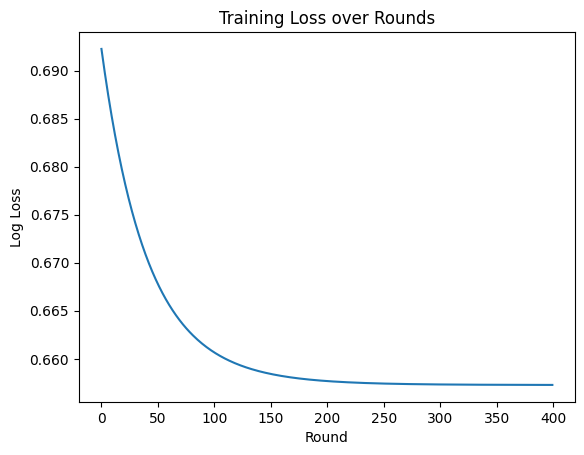

In [27]:
w = train_federated_FedAvg(X_train,y_train,n_rounds=400)

In [28]:
y_pred = predict_and_evaluate(X_test[:,1:],y_test,w)

                 precision    recall  f1-score   support

no complication       0.74      0.18      0.29      3073
   complication       0.41      0.90      0.56      1927

       accuracy                           0.46      5000
      macro avg       0.58      0.54      0.42      5000
   weighted avg       0.61      0.46      0.39      5000



# Fire modeller

In [29]:
def prepare_data_for_four_models(df,begin = 1, end = 27, cli = False, target = 'Complication'):
    # Prepare data
    features = df.columns.tolist()[begin:end]
    X = df[features].values
    y = df[target].values
    # Scale data (normalization)
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    if cli:
        X = np.c_[df['Client'],np.ones(X.shape[0]), X]
    else:
        X = np.c_[np.ones(X.shape[0]), X]

    # Split into training and test set
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16)
    
    return X_train, X_test, y_train, y_test

In [30]:
complications = ['Risk_NerveDysesthesia','Risk_Bleeding',\
                 'Risk_AlveolarOsteitis','Risk_SecondaryInfection']

In [36]:
def fed_train_all_complications(df,complications):
    weights = []
    predictions = []
    true_vals = []
    for c in complications:
        print(f'For complication {c}:')
        X_train, X_test, y_train, y_test = prepare_data_for_four_models(df, cli=True, target=c)
        true_vals.append(y_test)
        w = train_federated_FedAvg(X_train,y_train,n_rounds=500)
        weights.append(w)
        y_pred = predict_and_evaluate(X_test[:,1:],y_test,w, threshold=0.1)
        predictions.append(y_pred)
    return weights, predictions, true_vals
        


For complication Risk_NerveDysesthesia:


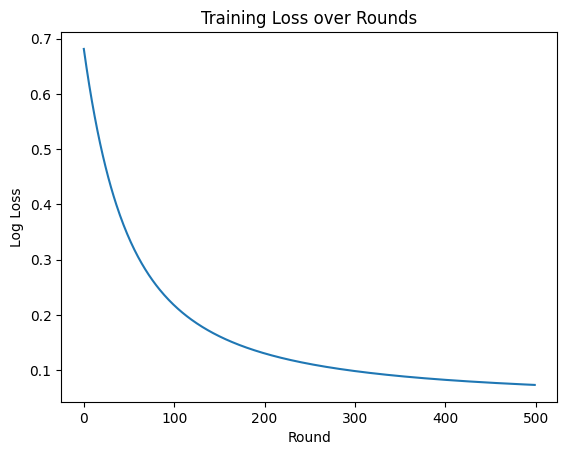

c:\Users\mejse\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mejse\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mejse\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

                 precision    recall  f1-score   support

no complication       0.99      1.00      1.00      4967
   complication       0.00      0.00      0.00        33

       accuracy                           0.99      5000
      macro avg       0.50      0.50      0.50      5000
   weighted avg       0.99      0.99      0.99      5000

For complication Risk_Bleeding:


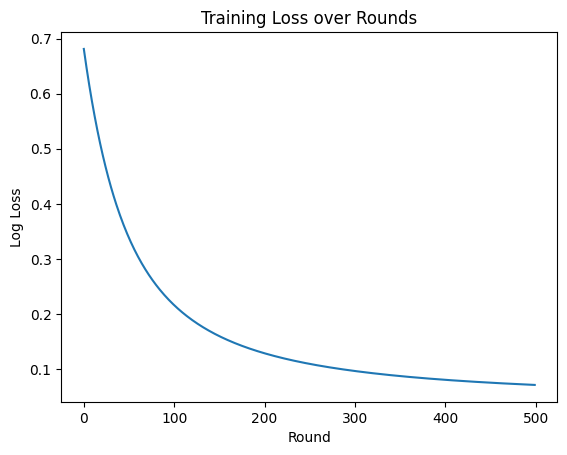

c:\Users\mejse\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mejse\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mejse\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

                 precision    recall  f1-score   support

no complication       0.99      1.00      1.00      4967
   complication       0.00      0.00      0.00        33

       accuracy                           0.99      5000
      macro avg       0.50      0.50      0.50      5000
   weighted avg       0.99      0.99      0.99      5000

For complication Risk_AlveolarOsteitis:


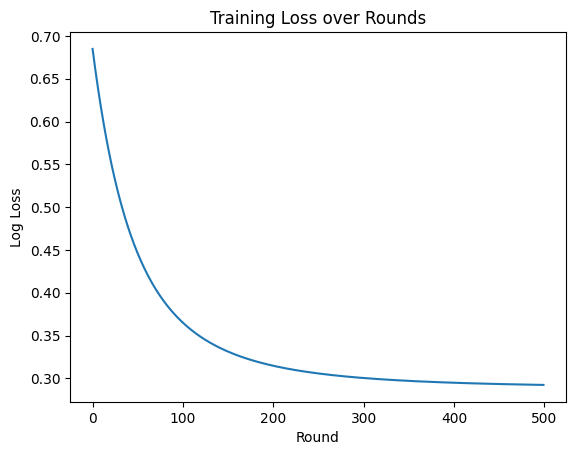

                 precision    recall  f1-score   support

no complication       0.95      0.51      0.66      4553
   complication       0.13      0.73      0.22       447

       accuracy                           0.53      5000
      macro avg       0.54      0.62      0.44      5000
   weighted avg       0.88      0.53      0.62      5000

For complication Risk_SecondaryInfection:


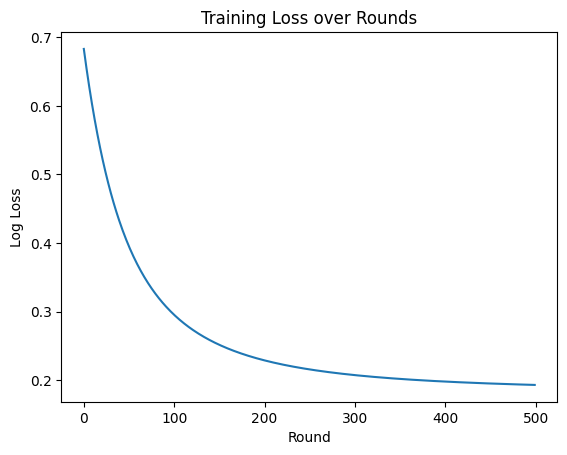

                 precision    recall  f1-score   support

no complication       0.96      0.82      0.89      4750
   complication       0.10      0.37      0.16       250

       accuracy                           0.80      5000
      macro avg       0.53      0.60      0.52      5000
   weighted avg       0.92      0.80      0.85      5000



In [37]:
weights, predictions, true_vals = fed_train_all_complications(df,complications)

The problem in the above plots is, that there are some complications that are so rare, that when using four models, instead of the binary like before, the models do not predict any positive cases. 

We still look at the magnitude of the coefficients, for one of the complications, that had some predicted cases.

In [42]:
def plot_magnitude(coefs, variable_names, title):
    fig, ax = plt.subplots(figsize=(10, 5))
    
    magnitudes = np.abs(coefs)
    
    ax.bar(range(len(coefs)), magnitudes)
    
    ax.set_xticks(range(len(coefs)))
    ax.set_xticklabels(variable_names, rotation=90)
    
    ax.set_title(title)
    ax.set_xlabel("Variables")
    ax.set_ylabel("|Coefficient|")
    
    plt.tight_layout()
    plt.show()

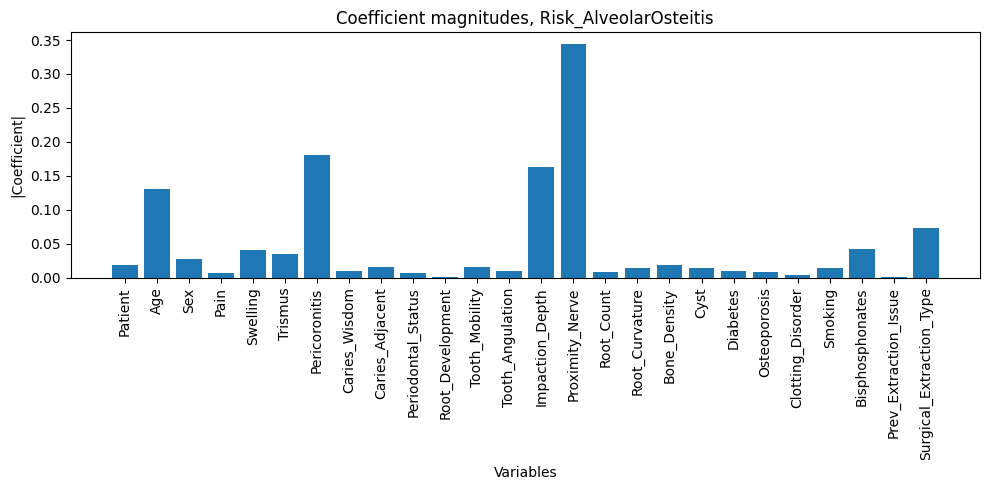

In [44]:
plot_magnitude(weights[2][1:], cols[1:27], title=f"Coefficient magnitudes, Risk_AlveolarOsteitis")

## categories

since the above worked so poorly, and we already know, that what we really want is to assign each patient with at label (low, mid, high), we do that now. Some of the below functions are from the multiple regression documents.

In [46]:
def prepare_data_for_four_models_category(df,begin = 1, end = 49, cli = False):
                                          
    # Prepare data
    features = df.columns.tolist()[begin:end]
    X = df[features].values

    # Scale data (normalization)
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X[1:27] = scaler.fit_transform(X[1:27])
    if cli:
        X = np.c_[df['Client'],np.ones(X.shape[0]), X]
    else:
        X = np.c_[np.ones(X.shape[0]), X]

    # Split into training and test set
    from sklearn.model_selection import train_test_split
    X_train, X_test = train_test_split(X, test_size=0.25, random_state=16)
    
    return X_train, X_test

In [47]:
y_hat = sigmoid(X_train[:,1:] @ weights[2])

In [48]:
def assign_tertiles(y_hat):
    """
    Deler y_hat i 3 grupper baseret på 1/3 og 2/3 kvantiler.
    Returnerer både gruppe-labels og grænserne.
    """
    q1 = np.quantile(y_hat, 1/3)
    q2 = np.quantile(y_hat, 2/3)

    groups = np.where(
        y_hat <= q1, 0,
        np.where(y_hat <= q2, 1, 2)
    )

    return groups, q1, q2

In [49]:
preds,q1,q2 = assign_tertiles(y_hat)

In [50]:
import numpy as np

def f1_macro_score(y_true, y_pred, classes=[0,1,2]):
    f1_scores = []

    for c in classes:
        # True positives, false positives, false negatives
        tp = np.sum((y_true == c) & (y_pred == c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))

        # Precision og recall (undgå division med 0)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0

        # F1 score for klassen
        if precision + recall > 0:
            f1 = 2 * (precision * recall) / (precision + recall)
        else:
            f1 = 0

        f1_scores.append(f1)

    # Macro = gennemsnit over klasser
    return np.mean(f1_scores)

In [51]:
train, test = prepare_data_for_four_models_category(df, cli = True)
y_true = train[:,-6]
f1_macro_score(y_true, preds)

np.float64(0.6699624103840961)

The below is plots, showing the magnitude of the coefficients, when using the 3 classes, and four models, as well as the corresponding f1-score. We see, that it is the same as for the Multiple regression.

since we see, that the results are the same, as for the multiple regression, we choose to stop here with the logistic regression, and do not pursue this method further.

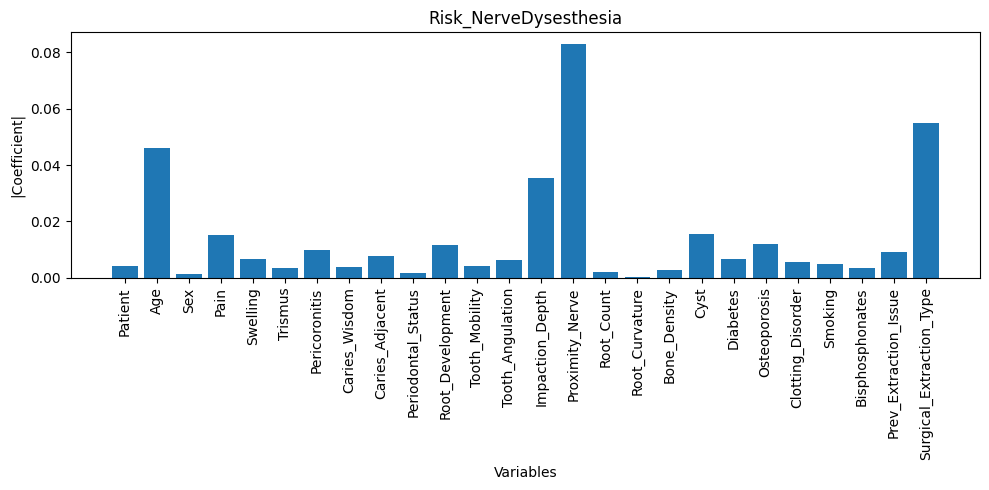

0.5852570124636248


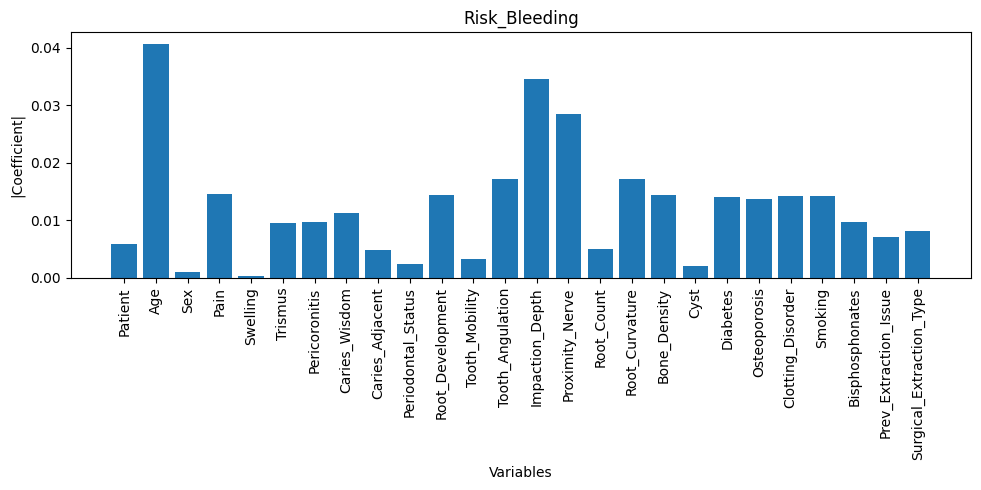

0.5406067440421197


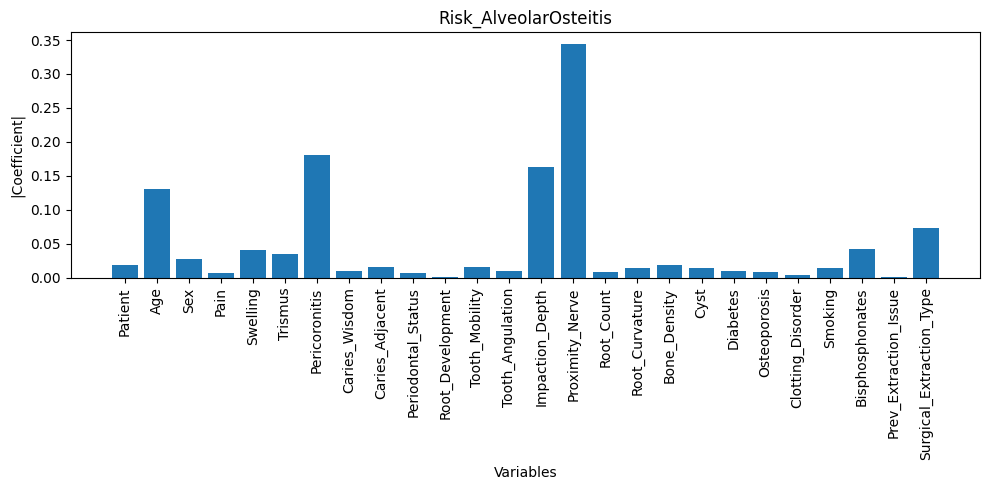

0.6699624103840961


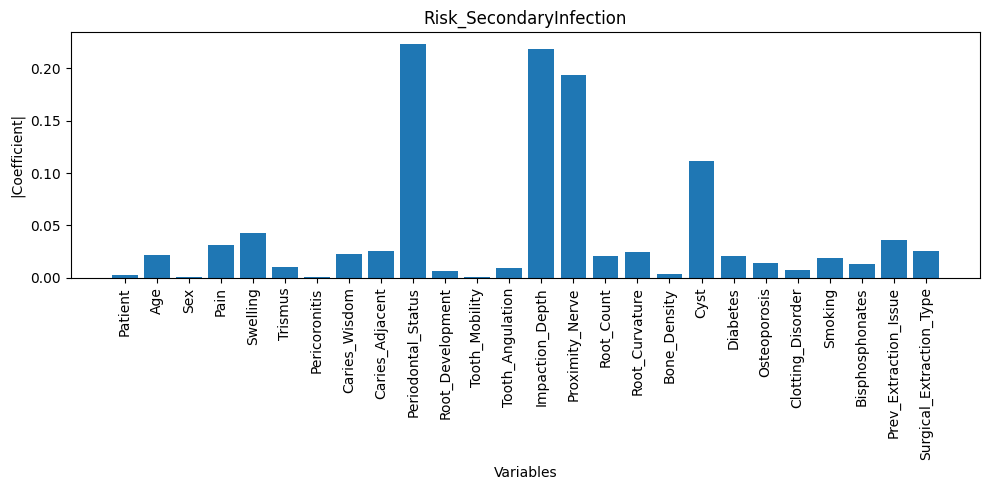

0.556818815818911


In [52]:
loc = [-4,-3,-6,-5]
for i in range(4):
    plot_magnitude(weights[i][1:], cols[1:27], title=complications[i])
    y_hat = sigmoid(X_train[:,1:] @ weights[i])
    train, test = prepare_data_for_four_models_category(df, cli = True)
    y_true = train[:,loc[i]]
    f1 = f1_macro_score(y_true, preds)
    print(f1)